<a href="https://colab.research.google.com/github/satish308/ai-mentor-portfolio./blob/main/Day6_PlacementProcessor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install -q chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [1]:
!pip install -q google-genai pydantic


In [2]:
import os, getpass
if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = getpass.getpass('Gemini API key: ')

Gemini API key: ··········


In [3]:
from pydantic import BaseModel
from typing import List, Optional

class Education(BaseModel):
    degree: str
    institution: str
    year: int

class Resume(BaseModel):
    name: str
    email: str
    phone: Optional[str] = None
    education: List[Education]
    skills: List[str]
    projects: List[str] = []
    experience_years: float


In [4]:
from google import genai
from pydantic import ValidationError

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])

def extract_resume(raw_text: str, max_retries: int = 1) -> Resume:
    """Extract a Resume JSON from raw text. Retries once on schema fail."""
    for attempt in range(max_retries + 1):
        try:
            resp = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'Extract a Resume JSON from this text. Return ONLY JSON, no markdown.\n\n{raw_text}',
                config={
                    'response_mime_type': 'application/json',
                    'response_schema': Resume.model_json_schema(),
                },
            )
            return Resume.model_validate_json(resp.text)
        except ValidationError as e:
            if attempt == max_retries:
                raise
            fix_prompt = f'Fix this JSON to match schema. Errors: {e}. Original: {resp.text}'
            resp = client.models.generate_content(
                model='gemini-2.5-flash', contents=fix_prompt,
                config={'response_mime_type': 'application/json',
                        'response_schema': Resume.model_json_schema()})
            return Resume.model_validate_json(resp.text)

In [6]:
# Load 5 sample résumés
with open('/content/sample_data/sample_resumes (1).txt') as f:
    resumes = [r.strip() for r in f.read().split('---') if r.strip()]
print(f'Loaded {len(resumes)} sample résumés')

results = []
errors = []
for i, r in enumerate(resumes):
    try:
        parsed = extract_resume(r)
        results.append(parsed)
        print(f'  [{i+1}] {parsed.name} — {len(parsed.skills)} skills')
    except Exception as e:
        errors.append((i, e))
        print(f'  [{i+1}] FAILED: {type(e).__name__}: {str(e)[:120]}')

print(f'\n{len(results)}/5 succeeded, {len(errors)} failed')

Loaded 5 sample résumés
  [1] FAILED: ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
  [2] Sneha Reddy — 6 skills
  [3] Arun Pillai — 8 skills
  [4] Priya Nair — 5 skills
  [5] Karthik Sharma — 5 skills

4/5 succeeded, 1 failed


In [7]:
# Empty string
try:
    bad = extract_resume('')
    print('Unexpected success:', bad.model_dump_json())
except Exception as e:
    print(f'Empty input: {type(e).__name__}: {str(e)[:200]}')

# Whitespace only
try:
    bad = extract_resume('   \n\n   ')
    print('Unexpected success:', bad.model_dump_json())
except Exception as e:
    print(f'Whitespace input: {type(e).__name__}: {str(e)[:200]}')

# Garbage non-résumé text
try:
    bad = extract_resume('the quick brown fox jumps over the lazy dog')
    print('Garbage input:', bad.model_dump_json())
except Exception as e:
    print(f'Garbage input: {type(e).__name__}: {str(e)[:200]}')

Unexpected success: {"name":"Jane Doe","email":"jane.doe@example.com","phone":"123-456-7890","education":[{"degree":"Master of Science in Computer Science","institution":"University of Technology","year":2020},{"degree":"Bachelor of Science in Software Engineering","institution":"State University","year":2018}],"skills":["Python","Java","JavaScript","React","SQL","AWS","Machine Learning","Data Analysis"],"projects":["E-commerce Platform Development","AI-powered Recommendation System","Mobile App for Task Management"],"experience_years":3.5}
Unexpected success: {"name":"","email":"","phone":null,"education":[],"skills":[],"projects":[],"experience_years":0.0}
Garbage input: {"name":"","email":"","phone":null,"education":[],"skills":[],"projects":[],"experience_years":0.0}


In [8]:
class JD(BaseModel):
    company: str
    role: str
    must_have_skills: List[str]
    nice_to_have_skills: List[str] = []
    min_cgpa: Optional[float] = None
    locations: List[str] = []
    package_lpa: Optional[float] = None

In [10]:
import requests
from bs4 import BeautifulSoup
import pathlib, json

def fetch_jd(url, max_chars=6000):
    """Fetch JD URL and return clean text. Returns None on block / failure."""
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, 'html.parser')
        # Remove script and style tags
        for tag in soup(['script', 'style']):
            tag.decompose()
        return soup.get_text(separator='\n', strip=True)[:max_chars]
    except Exception as e:
        print(f'  Scrape failed for {url}: {e}')
        return None

# Test on one URL
test_url = 'https://amazon.jobs/en/jobs/10426444/risk-specialist-turkish-fdap-financial-risk-mitigation'
text = fetch_jd(test_url)
if text:
    print(f'Got {len(text)} chars')
    print(text[:300])
else:
    print('Scrape blocked. Will use cached set.')

Got 5097 chars
Risk Specialist Turkish- FDAP,, Financial Risk Mitigation - Job ID: 10426444 | Amazon.jobs
Skip to main content
×
Home
Teams
Locations
Job categories
My career
My applications
My profile
Account security
Settings
Sign out
Resources
Accommodations
Benefits
Inclusive experiences
How We Hire
Leadership


In [11]:
def normalise_jd(text: str) -> JD:
    """Send JD text to Gemini, get structured JD JSON back."""
    resp = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=f'Extract a JD JSON from this text:\n\n{text}',
        config={
            'response_mime_type': 'application/json',
            'response_schema': JD.model_json_schema(),
        },
    )
    return JD.model_validate_json(resp.text)

# Test on one JD text
if text:
    jd = normalise_jd(text)
    print(jd.model_dump_json(indent=2))

{
  "company": "Amazon",
  "role": "Risk Specialist",
  "must_have_skills": [
    "Proficiency in Turkish (reading, listening, speaking, writing)",
    "Proficiency in English (reading, listening, speaking, writing)",
    "Microsoft Office (including Excel and Word)",
    "Time management",
    "Written and verbal communication",
    "Handling confidential information",
    "Fraud investigation",
    "Data analysis",
    "SQL"
  ],
  "nice_to_have_skills": [
    "Experience with AI systems",
    "Experience in law",
    "Experience in customer service",
    "Experience in project management",
    "Communicating complex concepts"
  ],
  "min_cgpa": null,
  "locations": [
    "Bengaluru, Karnataka, India"
  ],
  "package_lpa": null
}


In [12]:
import json, pathlib

URLS = [
    # Paste your 5 assigned URLs here
    'https://amazon.jobs/en/jobs/10382448/associate-corporate-counsel',
    'https://amazon.jobs/en/jobs/10410004/applied-scientist-ii-on-road-experience',
    'https://amazon.jobs/en/jobs/3207573/data-scientist-maple-recommender-system',
    'https://amazon.jobs/en/jobs/10429158/product-manager-amazon-payment-services',
    'https://amazon.jobs/en/jobs/3207578/applied-scientist-maple-recommender-system',
]

CACHE = pathlib.Path('../data/jds_cached.jsonl')
USE_CACHE = False   # set True if scraping is blocked

jds = []

if USE_CACHE and CACHE.exists():
    print(f'Using cached JDs from {CACHE}')
    for line in CACHE.read_text().splitlines():
        jds.append(JD.model_validate_json(line))
else:
    for url in URLS:
        text = fetch_jd(url)
        if text is None:
            continue
        try:
            jd = normalise_jd(text)
            jds.append(jd)
            print(f'  ✓ {jd.company} — {jd.role}')
        except Exception as e:
            print(f'  ✗ {url}: {e}')

print(f'\nProcessed {len(jds)} JDs')

# Inspect first 3
for jd in jds[:3]:
    print(f'\n{jd.company} - {jd.role}')
    print(f'  Must: {jd.must_have_skills}')
    print(f'  Nice: {jd.nice_to_have_skills}')
    print(f'  CGPA: {jd.min_cgpa}, LPA: {jd.package_lpa}')

  ✗ https://amazon.jobs/en/jobs/10382448/associate-corporate-counsel: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
  ✓ Amazon — Applied Scientist II, On Road Experience
  ✓ Amazon — Data Scientist, MAPLE - Recommender System
  Scrape failed for https://amazon.jobs/en/jobs/10429158/product-manager-amazon-payment-services: ('Received response with content-encoding: zstd, but failed to decode it.', ZstdError('cannot use a decompressobj multiple times'))
  Scrape failed for https://amazon.jobs/en/jobs/3207578/applied-scientist-maple-recommender-system: ('Received response with content-encoding: zstd, but failed to decode it.', ZstdError('cannot use a decompressobj multiple times'))

Processed 2 JDs

Amazon - Applied Scientist II, On Road Experience
  Must: ['Java', 'C++', 'Python', 'algorithms and data structures', 'parsing', 'numerical optim

In [13]:
OUT = pathlib.Path('data/jds.jsonl')
OUT.parent.mkdir(exist_ok=True)
with open(OUT, 'w') as f:
    for jd in jds:
        f.write(jd.model_dump_json() + '\n')
print(f'Wrote {len(jds)} JDs to {OUT}')

# Verify the file
with open(OUT) as f:
    for line in f:
        d = json.loads(line)
        print(f'  {d["company"]:20} | {d["role"]:30} | {len(d["must_have_skills"])} must-haves')

Wrote 2 JDs to data/jds.jsonl
  Amazon               | Applied Scientist II, On Road Experience | 9 must-haves
  Amazon               | Data Scientist, MAPLE - Recommender System | 8 must-haves


In [14]:
with open('/content/cse_sem5.txt') as f:
    text = f.read()

# Split on blank lines into paragraphs
paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()][:10]

print(f'Loaded {len(paragraphs)} paragraphs')
for i, p in enumerate(paragraphs):
    print(f'  [{i+1}] {p[:80]}')

Loaded 7 paragraphs
  [1] CSE Semester 5 — Syllabus Excerpt
  [2] Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF
  [3] Database Management Systems:
ER model, relational model, normalisation (1NF thro
  [4] Computer Networks:
OSI and TCP/IP models. Physical, data link, network, transpor
  [5] Software Engineering:
SDLC models: waterfall, agile, scrum.
Requirements enginee
  [6] Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [7] Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit


In [20]:
from chromadb import PersistentClient
from sentence_transformers import SentenceTransformer

client = PersistentClient(path='./chroma_db')
col = client.get_or_create_collection('hello_syllabus')

# Initialize the embedding model
embed = SentenceTransformer('all-MiniLM-L6-v2') # You can choose another suitable model

# Embed all 10 paragraphs
vectors = embed.encode(paragraphs).tolist()

# Add to collection (with sequential IDs)
col.add(
    documents=paragraphs,
    embeddings=vectors,
    ids=[f'p{i}' for i in range(len(paragraphs))]
)

print(f'Indexed {col.count()} documents')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexed 7 documents


In [21]:
queries = [
    'what is dynamic programming?',
    'machine learning topics',
    'operating system processes',
]

for q in queries:
    print(f'\nQuery: {q}')
    qv = embed.encode([q]).tolist()
    results = col.query(query_embeddings=qv, n_results=3)
    docs = results['documents'][0]
    distances = results['distances'][0]
    for j, (d, dist) in enumerate(zip(docs, distances)):
        print(f'  [{j+1}] (dist={dist:.3f}) {d[:80]}')


Query: what is dynamic programming?
  [1] (dist=1.464) Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [2] (dist=1.469) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit
  [3] (dist=1.476) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF

Query: machine learning topics
  [1] (dist=1.300) Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [2] (dist=1.526) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit
  [3] (dist=1.533) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF

Query: operating system processes
  [1] (dist=0.713) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF
  [2] (dist=1.246) Database Management Systems:
ER model, relational model, normalisation (1NF thro
  [3] (dist=1.370) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hos

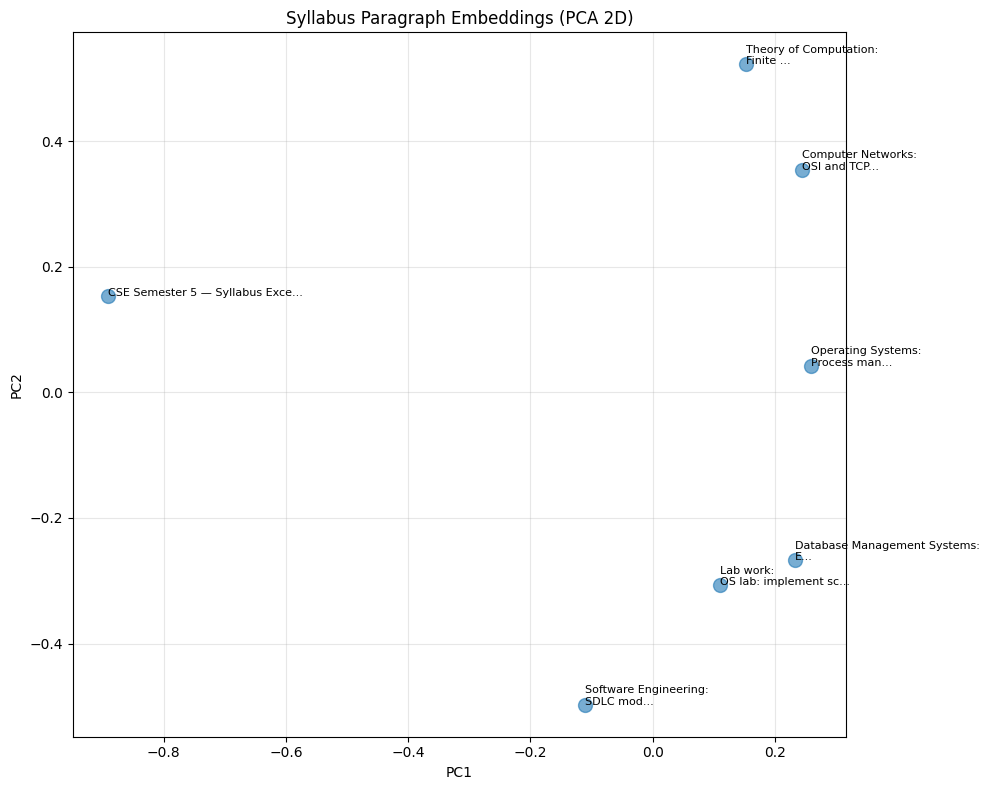

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

vectors_arr = np.array(vectors)

pca = PCA(n_components=2)
xy = pca.fit_transform(vectors_arr)

plt.figure(figsize=(10, 8))
plt.scatter(xy[:, 0], xy[:, 1], s=100, alpha=0.6)
for i, p in enumerate(paragraphs):
    label = p[:30] + '...' if len(p) > 30 else p
    plt.annotate(label, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('Syllabus Paragraph Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

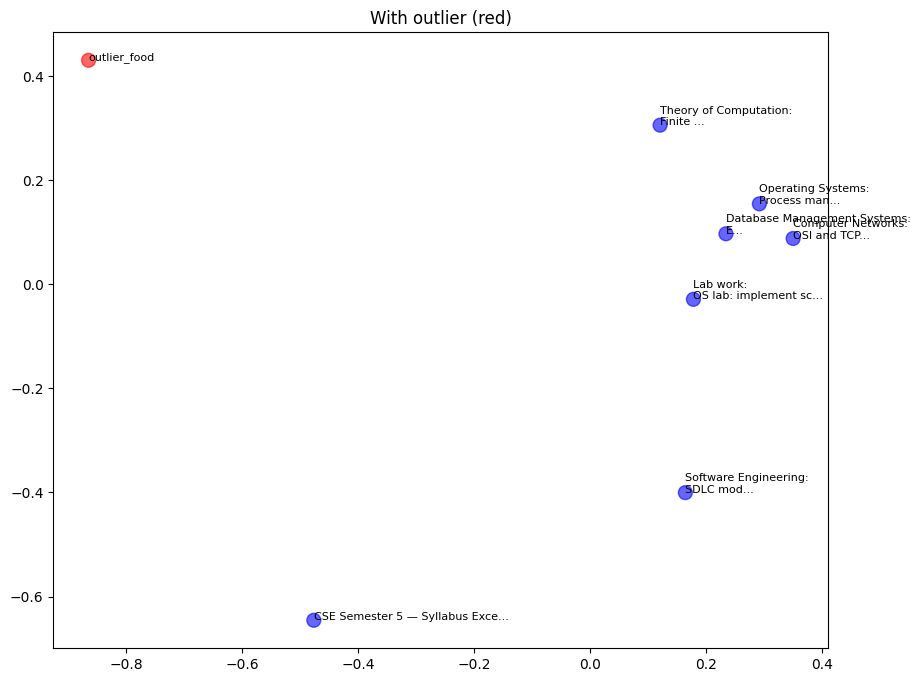

In [23]:
# Add a totally unrelated paragraph to see where it lands
outlier = "Today's special at the cafeteria is butter chicken with rice and naan."

col.add(
    documents=[outlier],
    embeddings=embed.encode([outlier]).tolist(),
    ids=['outlier_food']
)

# Re-fetch all and re-plot
all_docs = col.get(include=['embeddings', 'documents'])
all_vecs = np.array(all_docs['embeddings'])
labels = all_docs['ids']

pca = PCA(n_components=2) # Re-initialize PCA to ensure it fits the new data
xy = pca.fit_transform(all_vecs)
plt.figure(figsize=(10, 8))
colors = ['red' if 'outlier' in l else 'blue' for l in labels]
plt.scatter(xy[:, 0], xy[:, 1], c=colors, s=100, alpha=0.6)
for i, l in enumerate(labels):
    short = labels[i] if 'outlier' in labels[i] else all_docs['documents'][i][:30] + '...'
    plt.annotate(short, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('With outlier (red)')
plt.show()